Part 1: Setup and Data Preparation
Using device: cpu
Training size: 800
Test size: 200

Part 2: Define the Model
CircleModelV0(
  (layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=1, bias=True)
  )
)

Part 3: Loss Function and Optimizer
Loss function: BCEWithLogitsLoss()
Optimizer: Adam (lr=0.01)

Part 4: Training Loop
Epoch [10/100], Loss: 0.6939, Acc: 64.25%
Epoch [20/100], Loss: 0.6931, Acc: 48.88%
Epoch [30/100], Loss: 0.6931, Acc: 52.13%
Epoch [40/100], Loss: 0.6929, Acc: 50.38%
Epoch [50/100], Loss: 0.6929, Acc: 51.38%
Epoch [60/100], Loss: 0.6929, Acc: 51.50%
Epoch [70/100], Loss: 0.6929, Acc: 51.13%
Epoch [80/100], Loss: 0.6929, Acc: 51.63%
Epoch [90/100], Loss: 0.6929, Acc: 51.38%
Epoch [100/100], Loss: 0.6929, Acc: 51.25%

Training complete!

Part 5: Visualizing Training Progress


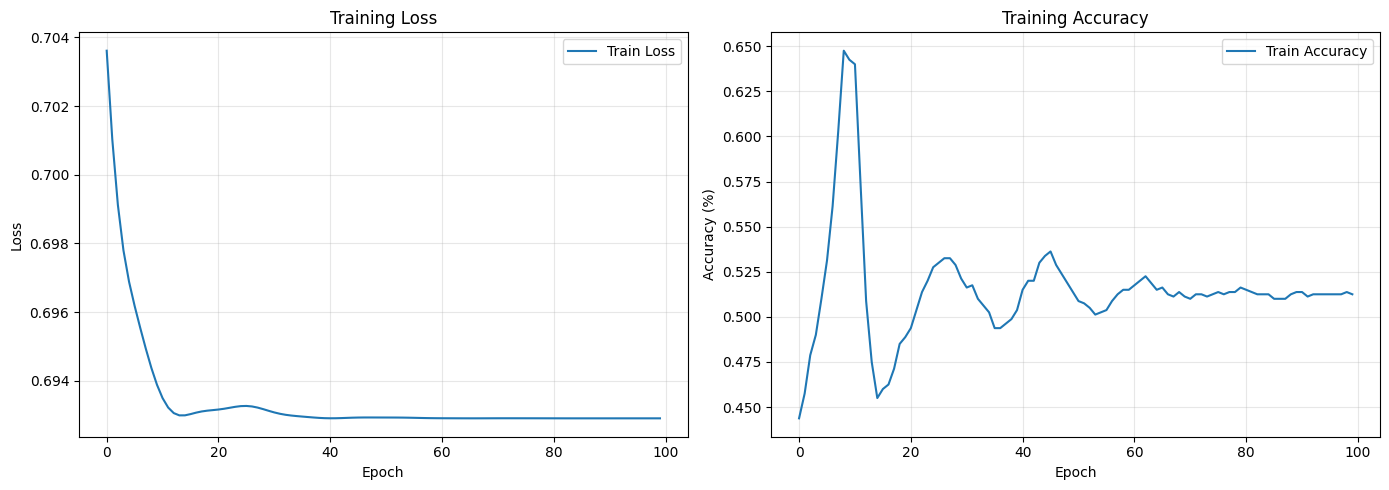

Training curves visualized!
Motto: Visualize, visualize, visualize!

Part 6: Inference Mode Predictions
Test Accuracy: 46.50%

First 5 predictions:
  Sample 1:
    Logits: 0.0257
    Probability: 0.5064
    Predicted: 1, Actual: 1.0
  Sample 2:
    Logits: 0.0713
    Probability: 0.5178
    Predicted: 1, Actual: 0.0
  Sample 3:
    Logits: -0.0242
    Probability: 0.4939
    Predicted: 0, Actual: 1.0
  Sample 4:
    Logits: 0.0640
    Probability: 0.5160
    Predicted: 1, Actual: 0.0
  Sample 5:
    Logits: -0.0286
    Probability: 0.4928
    Predicted: 0, Actual: 1.0

Part 7: Understanding Evaluation Mode
model.eval() vs model.train():
  model.train() - Enables dropout and batch norm training behavior
  model.eval()  - Disables dropout, uses running statistics

torch.inference_mode():
  - Disables gradient calculation
  - Faster than torch.no_grad()
  - Use for making predictions

Correct inference pattern:
  model.eval()
  with torch.inference_mode():
      predictions = model(X)

Pa

C:\Users\HP\AppData\Local\Temp\ipykernel_9192\3844499168.py:257: UserWarning: You passed a edgecolor/edgecolors ('r') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test_cpu[incorrect_mask, 0], X_test_cpu[incorrect_mask, 1],


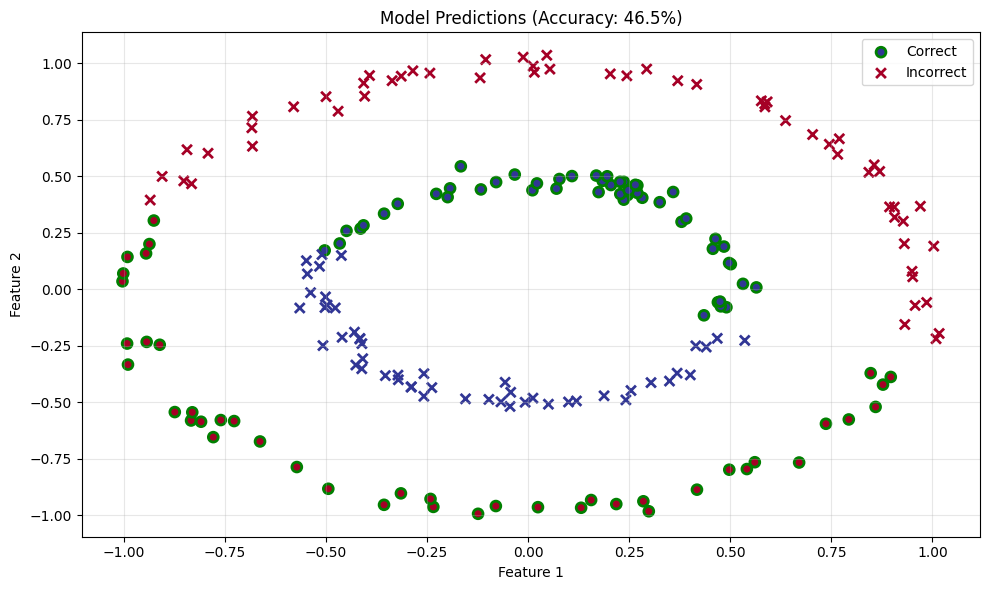


Exercises

Exercise 1: Try different thresholds
Experiment with different decision thresholds:
  - threshold=0.3 (more sensitive to class 1)
  - threshold=0.5 (default)
  - threshold=0.7 (less sensitive to class 1)
Tip: Modify (test_probs > 0.5) to use different thresholds

Exercise 2: Experiment with learning rate
Try different learning rates:
  - lr=0.001 (slower learning)
  - lr=0.01 (default)
  - lr=0.1 (faster learning, may be unstable)
Tip: Modify the 'lr' parameter in optim.Adam()

Exercise 3: Analyze training curves
Questions to answer:
  - Is the loss decreasing steadily?
  - Is the training plateauing?
  - Would more epochs help?
Tip: Look at the loss and accuracy curves

Exercise 4: Experiment with epochs
Try different numbers of epochs:
  - epochs=50 (less training)
  - epochs=100 (default)
  - epochs=200 (more training)
Tip: Modify the 'epochs' variable

Exercise 5: Understand model.eval()
Question: What happens if you forget to call model.eval() before testing?
Tip: Try 

In [4]:
"""
Exercise 2: Training and Predictions
Neural Network Classification - Module 3

This exercise covers:
- Implementing the 5-step training loop
- Converting logits → probabilities → labels
- Using model.eval() and torch.inference_mode()
- Tracking training progress
- Calculating accuracy

Learning Mottos:
- If in doubt, run the code!
- Experiment, experiment, experiment!
- Visualize, visualize, visualize!
"""

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
import numpy as np

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# ============================================
# Part 1: Setup and Data Preparation
# ============================================

print("=" * 60)
print("Part 1: Setup and Data Preparation")
print("=" * 60)

# Create dataset
X, y = make_circles(n_samples=1000, noise=0.03, factor=0.5, random_state=42)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Convert to PyTorch tensors
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train).unsqueeze(1)
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test).unsqueeze(1)

# Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Move to device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

print(f"Training size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

# ============================================
# Part 2: Define the Model
# ============================================

print("\n" + "=" * 60)
print("Part 2: Define the Model")
print("=" * 60)

# Define linear model
class CircleModelV0(nn.Module):
    def __init__(self):
        super(CircleModelV0, self).__init__()
        self.layer_stack = nn.Sequential(
            nn.Linear(2, 8),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.layer_stack(x)

model = CircleModelV0().to(device)
print(model)

# ============================================
# Part 3: Loss Function and Optimizer
# ============================================

print("\n" + "=" * 60)
print("Part 3: Loss Function and Optimizer")
print("=" * 60)

# Loss function for binary classification
criterion = nn.BCEWithLogitsLoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.01)

print(f"Loss function: BCEWithLogitsLoss()")
print(f"Optimizer: Adam (lr=0.01)")

# ============================================
# Part 4: Training Loop (5 Steps)
# ============================================

print("\n" + "=" * 60)
print("Part 4: Training Loop")
print("=" * 60)

epochs = 100
train_losses = []
train_accuracies = []

model.train()
for epoch in range(epochs):
    # Step 1: Forward pass
    y_logits = model(X_train)

    # Step 2: Calculate loss
    loss = criterion(y_logits, y_train)

    # Step 3: Zero gradients
    optimizer.zero_grad()

    # Step 4: Backward pass
    loss.backward()

    # Step 5: Optimizer step
    optimizer.step()

    # Track metrics
    train_losses.append(loss.item())
    with torch.no_grad():
        y_pred = (torch.sigmoid(y_logits) > 0.5).long()
        accuracy = (y_pred == y_train).float().mean()
        train_accuracies.append(accuracy.item())

    # Print progress
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, Acc: {accuracy.item()*100:.2f}%')

print("\nTraining complete!")

# ============================================
# Part 5: Visualizing Training Progress
# ============================================

print("\n" + "=" * 60)
print("Part 5: Visualizing Training Progress")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(train_losses, label='Train Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(train_accuracies, label='Train Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Training curves visualized!")
print("Motto: Visualize, visualize, visualize!")

# ============================================
# Part 6: Inference Mode Predictions
# ============================================

print("\n" + "=" * 60)
print("Part 6: Inference Mode Predictions")
print("=" * 60)

# Set model to evaluation mode
model.eval()

# Make predictions using inference mode
with torch.inference_mode():
    # Forward pass (raw logits)
    test_logits = model(X_test)

    # Convert to probabilities
    test_probs = torch.sigmoid(test_logits)

    # Convert to labels
    test_preds = (test_probs > 0.5).long()

# Calculate test accuracy
test_accuracy = (test_preds == y_test).float().mean()
print(f"Test Accuracy: {test_accuracy.item()*100:.2f}%")

# Show some examples
print("\nFirst 5 predictions:")
for i in range(5):
    print(f"  Sample {i+1}:")
    print(f"    Logits: {test_logits[i].item():.4f}")
    print(f"    Probability: {test_probs[i].item():.4f}")
    print(f"    Predicted: {test_preds[i].item()}, Actual: {y_test[i].item()}")

# ============================================
# Part 7: Understanding model.eval() and torch.inference_mode()
# ============================================

print("\n" + "=" * 60)
print("Part 7: Understanding Evaluation Mode")
print("=" * 60)

print("model.eval() vs model.train():")
print("  model.train() - Enables dropout and batch norm training behavior")
print("  model.eval()  - Disables dropout, uses running statistics")

print("\ntorch.inference_mode():")
print("  - Disables gradient calculation")
print("  - Faster than torch.no_grad()")
print("  - Use for making predictions")

print("\nCorrect inference pattern:")
print("  model.eval()")
print("  with torch.inference_mode():")
print("      predictions = model(X)")

# ============================================
# Part 8: Predictions Visualization
# ============================================

print("\n" + "=" * 60)
print("Part 8: Visualizing Predictions")
print("=" * 60)

# Move data to CPU for plotting
X_test_cpu = X_test.cpu().numpy()
y_test_cpu = y_test.cpu().numpy().squeeze()
test_preds_cpu = test_preds.cpu().numpy().squeeze()

# Plot predictions
plt.figure(figsize=(10, 6))

# Correct predictions (green circles)
correct_mask = test_preds_cpu == y_test_cpu
plt.scatter(X_test_cpu[correct_mask, 0], X_test_cpu[correct_mask, 1],
            c=y_test_cpu[correct_mask], cmap='RdYlBu', s=50,
            marker='o', edgecolors='g', linewidths=2, label='Correct')

# Incorrect predictions (red X)
incorrect_mask = ~correct_mask
plt.scatter(X_test_cpu[incorrect_mask, 0], X_test_cpu[incorrect_mask, 1],
            c=y_test_cpu[incorrect_mask], cmap='RdYlBu', s=50,
            marker='x', edgecolors='r', linewidths=2, label='Incorrect')

plt.title(f'Model Predictions (Accuracy: {test_accuracy.item()*100:.1f}%)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================
# Exercises
# ============================================

print("\n" + "=" * 60)
print("Exercises")
print("=" * 60)

# Exercise 1: Try different thresholds
print("\nExercise 1: Try different thresholds")
print("Experiment with different decision thresholds:")
print("  - threshold=0.3 (more sensitive to class 1)")
print("  - threshold=0.5 (default)")
print("  - threshold=0.7 (less sensitive to class 1)")
print("Tip: Modify (test_probs > 0.5) to use different thresholds")

# Exercise 2: Experiment with learning rate
print("\nExercise 2: Experiment with learning rate")
print("Try different learning rates:")
print("  - lr=0.001 (slower learning)")
print("  - lr=0.01 (default)")
print("  - lr=0.1 (faster learning, may be unstable)")
print("Tip: Modify the 'lr' parameter in optim.Adam()")

# Exercise 3: Track loss over epochs
print("\nExercise 3: Analyze training curves")
print("Questions to answer:")
print("  - Is the loss decreasing steadily?")
print("  - Is the training plateauing?")
print("  - Would more epochs help?")
print("Tip: Look at the loss and accuracy curves")

# Exercise 4: Experiment with epochs
print("\nExercise 4: Experiment with epochs")
print("Try different numbers of epochs:")
print("  - epochs=50 (less training)")
print("  - epochs=100 (default)")
print("  - epochs=200 (more training)")
print("Tip: Modify the 'epochs' variable")

# Exercise 5: Compare model.eval() vs not using it
print("\nExercise 5: Understand model.eval()")
print("Question: What happens if you forget to call model.eval() before testing?")
print("Tip: Try commenting out model.eval() and see if results change")

print("\n" + "=" * 60)
print("Exercise 2 Complete!")
print("Remember: If in doubt, run the code!")
print("Remember: Experiment, experiment, experiment!")
print("Remember: Visualize, visualize, visualize!")
print("=" * 60)


# Exercise 1: Try different thresholds
Experiment with different decision thresholds:
- threshold=0.3 (more sensitive to class 1)
- threshold=0.5 (default)
- threshold=0.7 (less sensitive to class 1)
Tip: Modify (test_probs > 0.5) to use different thresholds


Threshold: 0.3
  Accuracy: 50.00%

Threshold: 0.5
  Accuracy: 46.50%

Threshold: 0.7
  Accuracy: 50.00%


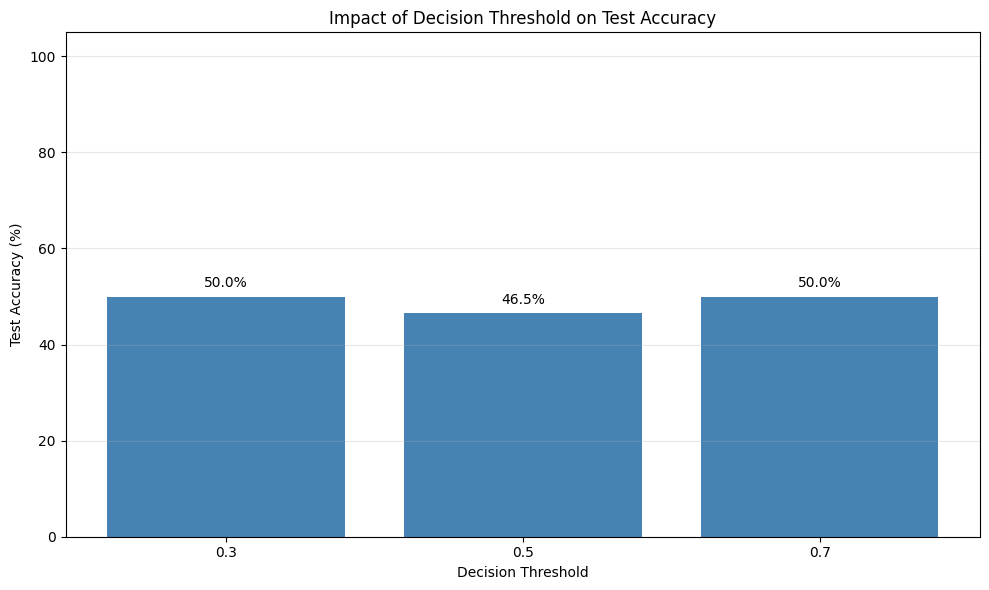

In [5]:
thresholds = [0.3, 0.5, 0.7]
threshold_results = {}

for threshold in thresholds:
    # Apply different threshold
    test_preds_threshold = (test_probs > threshold).long()
    
    # Calculate accuracy
    accuracy = (test_preds_threshold == y_test).float().mean()
    threshold_results[threshold] = accuracy.item()
    
    print(f"\nThreshold: {threshold}")
    print(f"  Accuracy: {accuracy.item()*100:.2f}%")

# Visualize threshold comparison
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar([str(t) for t in thresholds], [threshold_results[t]*100 for t in thresholds], color='steelblue')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Impact of Decision Threshold on Test Accuracy')
ax.set_ylim([0, 105])
for i, threshold in enumerate(thresholds):
    ax.text(i, threshold_results[threshold]*100 + 2, f"{threshold_results[threshold]*100:.1f}%", ha='center')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Exercise 2: Experiment with learning rate
Try different learning rates:
- lr=0.001 (slower learning)
- lr=0.01 (default)
- lr=0.1 (faster learning, may be unstable)


Learning Rate: 0.001
  Final Loss: 0.6929
  Test Accuracy: 45.00%

Learning Rate: 0.01
  Final Loss: 0.6929
  Test Accuracy: 46.50%

Learning Rate: 0.1
  Final Loss: 0.6929
  Test Accuracy: 46.50%


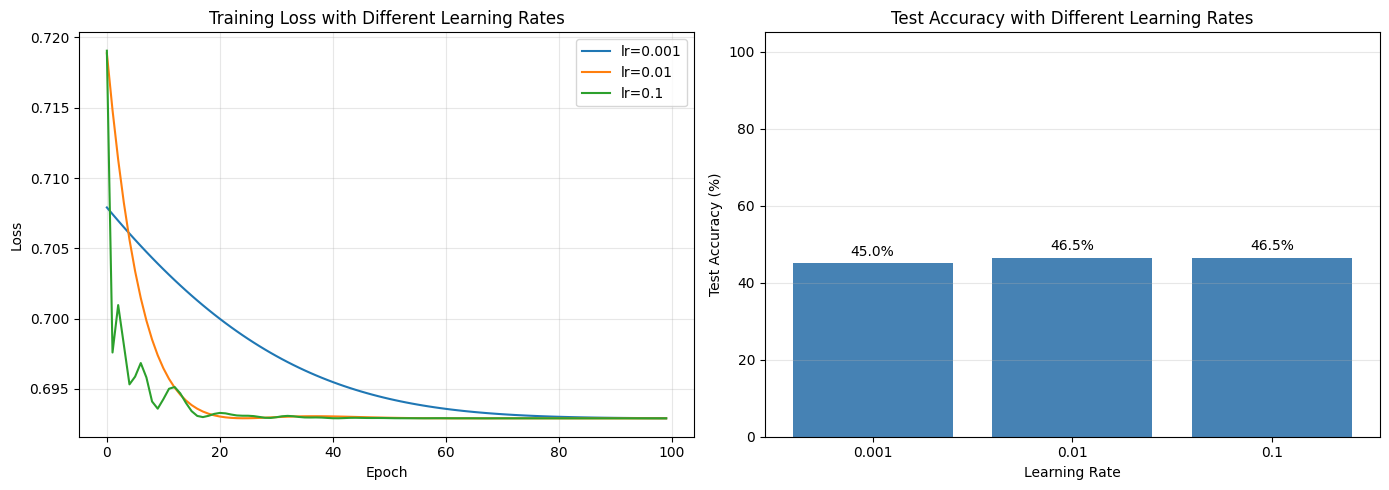

In [6]:
learning_rates = [0.001, 0.01, 0.1]
lr_results = {}

for lr in learning_rates:
    # Reset model
    model_lr = CircleModelV0().to(device)
    criterion_lr = nn.BCEWithLogitsLoss()
    optimizer_lr = optim.Adam(model_lr.parameters(), lr=lr)
    
    # Train
    model_lr.train()
    train_losses_lr = []
    for epoch in range(100):
        y_logits = model_lr(X_train)
        loss = criterion_lr(y_logits, y_train)
        optimizer_lr.zero_grad()
        loss.backward()
        optimizer_lr.step()
        train_losses_lr.append(loss.item())
    
    # Test
    model_lr.eval()
    with torch.inference_mode():
        test_logits_lr = model_lr(X_test)
        test_probs_lr = torch.sigmoid(test_logits_lr)
        test_preds_lr = (test_probs_lr > 0.5).long()
    
    accuracy_lr = (test_preds_lr == y_test).float().mean()
    lr_results[lr] = {'accuracy': accuracy_lr.item(), 'losses': train_losses_lr}
    
    print(f"\nLearning Rate: {lr}")
    print(f"  Final Loss: {train_losses_lr[-1]:.4f}")
    print(f"  Test Accuracy: {accuracy_lr.item()*100:.2f}%")

# Visualize learning rate comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
for lr in learning_rates:
    axes[0].plot(lr_results[lr]['losses'], label=f'lr={lr}')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss with Different Learning Rates')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy comparison
axes[1].bar([str(lr) for lr in learning_rates], 
            [lr_results[lr]['accuracy']*100 for lr in learning_rates], 
            color='steelblue')
axes[1].set_xlabel('Learning Rate')
axes[1].set_ylabel('Test Accuracy (%)')
axes[1].set_title('Test Accuracy with Different Learning Rates')
axes[1].set_ylim([0, 105])
for i, lr in enumerate(learning_rates):
    axes[1].text(i, lr_results[lr]['accuracy']*100 + 2, 
                f"{lr_results[lr]['accuracy']*100:.1f}%", ha='center')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Exercise 3: Track loss over epochs
Questions to answer:
- Is the loss decreasing steadily?
- Is the training plateauing?
- Would more epochs help?

In [12]:
# Analyze loss progression
loss_diff = [train_losses[i+1] - train_losses[i] for i in range(len(train_losses)-1)]
avg_loss_diff_first_half = sum(loss_diff[:50]) / 50
avg_loss_diff_second_half = sum(loss_diff[50:]) / 50

print("\nLoss Analysis:")
print(f"  Average loss decrease (epochs 1-50): {avg_loss_diff_first_half:.6f}")
print(f"  Average loss decrease (epochs 51-100): {avg_loss_diff_second_half:.6f}")
print(f"  Initial loss: {train_losses[0]:.4f}")
print(f"  Final loss: {train_losses[-1]:.4f}")

# Check for plateauing
threshold = 0.0001
plateauing = sum(1 for diff in loss_diff[50:] if abs(diff) < threshold)
print(f"\n  Epochs where loss change < {threshold}: {plateauing}/50")

# Accuracy analysis
acc_improvement = train_accuracies[-1] - train_accuracies[0]
first_half_acc = train_accuracies[49]
second_half_acc = train_accuracies[-1]

print("\nAccuracy Analysis:")
print(f"  Initial accuracy: {train_accuracies[0]*100:.2f}%")
print(f"  Accuracy at epoch 50: {first_half_acc*100:.2f}%")
print(f"  Final accuracy: {second_half_acc*100:.2f}%")
print(f"  Total improvement: {acc_improvement*100:.2f}%")


Loss Analysis:
  Average loss decrease (epochs 1-50): -0.000214
  Average loss decrease (epochs 51-100): -0.000000
  Initial loss: 0.7036
  Final loss: 0.6929

  Epochs where loss change < 0.0001: 49/50

Accuracy Analysis:
  Initial accuracy: 44.37%
  Accuracy at epoch 50: 51.38%
  Final accuracy: 51.25%
  Total improvement: 6.87%


# Exercise 4: Experiment with epochs
Try different numbers of epochs:
- epochs=50 (less training)
- epochs=100 (default)
- epochs=200 (more training)


Epochs: 50
  Final Train Loss: 0.6930
  Final Train Accuracy: 42.38%
  Test Accuracy: 41.50%

Epochs: 100
  Final Train Loss: 0.6929
  Final Train Accuracy: 51.38%
  Test Accuracy: 47.00%

Epochs: 200
  Final Train Loss: 0.6929
  Final Train Accuracy: 51.25%
  Test Accuracy: 47.00%


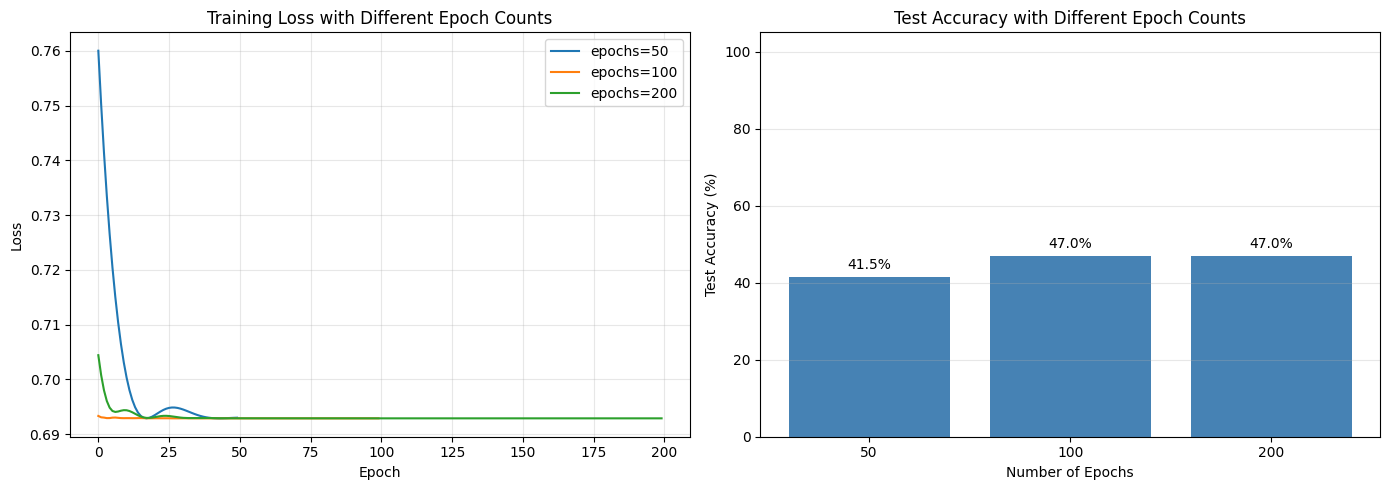

In [15]:
epochs_list = [50, 100, 200]
epochs_results = {}

for epochs in epochs_list:
    # Reset model
    model_epochs = CircleModelV0().to(device)
    criterion_epochs = nn.BCEWithLogitsLoss()
    optimizer_epochs = optim.Adam(model_epochs.parameters(), lr=0.01)
    
    # Train
    model_epochs.train()
    train_losses_epochs = []
    train_accs_epochs = []
    
    for epoch in range(epochs):
        y_logits = model_epochs(X_train)
        loss = criterion_epochs(y_logits, y_train)
        optimizer_epochs.zero_grad()
        loss.backward()
        optimizer_epochs.step()
        train_losses_epochs.append(loss.item())
        
        with torch.no_grad():
            y_pred_epoch = (torch.sigmoid(y_logits) > 0.5).long()
            acc = (y_pred_epoch == y_train).float().mean()
            train_accs_epochs.append(acc.item())
    
    # Test
    model_epochs.eval()
    with torch.inference_mode():
        test_logits_epochs = model_epochs(X_test)
        test_probs_epochs = torch.sigmoid(test_logits_epochs)
        test_preds_epochs = (test_probs_epochs > 0.5).long()
    
    accuracy_epochs = (test_preds_epochs == y_test).float().mean()
    epochs_results[epochs] = {
        'train_losses': train_losses_epochs,
        'train_accs': train_accs_epochs,
        'test_accuracy': accuracy_epochs.item()
    }
    
    print(f"\nEpochs: {epochs}")
    print(f"  Final Train Loss: {train_losses_epochs[-1]:.4f}")
    print(f"  Final Train Accuracy: {train_accs_epochs[-1]*100:.2f}%")
    print(f"  Test Accuracy: {accuracy_epochs.item()*100:.2f}%")

# Visualize epochs comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
for epochs in epochs_list:
    axes[0].plot(epochs_results[epochs]['train_losses'], label=f'epochs={epochs}')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss with Different Epoch Counts')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy comparison
axes[1].bar([str(e) for e in epochs_list], 
            [epochs_results[e]['test_accuracy']*100 for e in epochs_list],
            color='steelblue')
axes[1].set_xlabel('Number of Epochs')
axes[1].set_ylabel('Test Accuracy (%)')
axes[1].set_title('Test Accuracy with Different Epoch Counts')
axes[1].set_ylim([0, 105])
for i, epochs in enumerate(epochs_list):
    axes[1].text(i, epochs_results[epochs]['test_accuracy']*100 + 2,
                f"{epochs_results[epochs]['test_accuracy']*100:.1f}%", ha='center')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Exercise 5: Compare model.eval() vs not using it
Question: What happens if you forget to call model.eval() before testing?

In [17]:
ans = """The model will stay in training mode, which can change its behavior and give incorrect evaluation results."""
print(ans)

The model will stay in training mode, which can change its behavior and give incorrect evaluation results.
